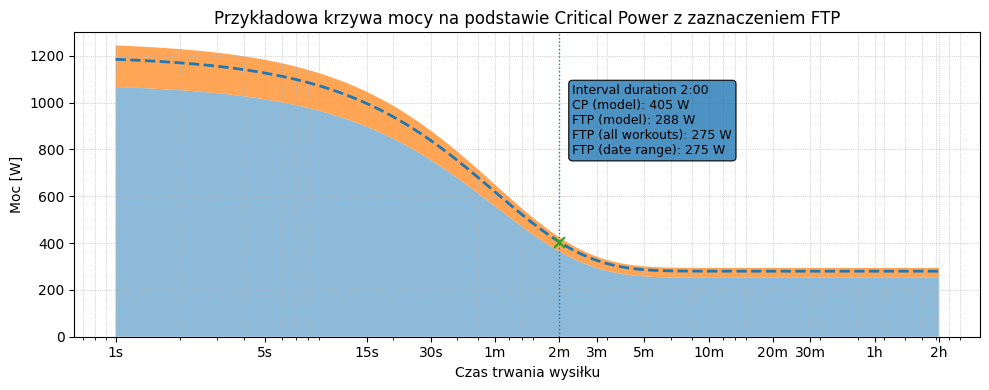

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Dane syntetyczne dla krzywej mocy (power-duration / critical power) ---

# czas od 1 s do 2 h (w sekundach), logarytmicznie
t = np.logspace(0, np.log10(7200), 300)

P_max = 1200  # przykładowa moc maksymalna (sprint)
CP = 280      # "docelowe" CP/FTP (wartość plateau)
tau = 60      # stała czasowa opadania mocy

# modelowana krzywa mocy
power = CP + (P_max - CP) * np.exp(-t / tau)

# górna i dolna "strefa" wokół krzywej (np. zakres historii treningów)
power_high = power * 1.05
power_low = power * 0.9

# --- Rysowanie wykresu ---

fig, ax = plt.subplots(figsize=(10, 4))

# wypełnienie dolnej strefy
ax.fill_between(t, 0, power_low, alpha=0.5)

# wypełnienie górnej strefy
ax.fill_between(t, power_low, power_high, alpha=0.7)

# przerywana linia – modelowana krzywa mocy
ax.plot(t, power, linestyle="--", linewidth=2)

# zaznaczenie interwału 2 min (jak na screenie)
t_mark = 120  # 2 minuty
p_mark = CP + (P_max - CP) * np.exp(-t_mark / tau)

ax.axvline(t_mark, linestyle=":", linewidth=1)
ax.scatter([t_mark], [p_mark], marker="x", s=60, zorder=5)

# przykładowe wartości do "dymka" opisowego
text = (
    "Interval duration 2:00\n"
    f"CP (model): {p_mark:.0f} W\n"
    "FTP (model): 288 W\n"
    "FTP (all workouts): 275 W\n"
    "FTP (date range): 275 W"
)

ax.text(
    0.55, 0.6, text,
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", alpha=0.8)
)

# --- Opisy osi i formatowanie ---

ax.set_xscale("log")
ax.set_xlabel("Czas trwania wysiłku")
ax.set_ylabel("Moc [W]")
ax.set_title("Przykładowa krzywa mocy na podstawie Critical Power z zaznaczeniem FTP")

# własne ticki na osi X (podobne do oryginału)
xticks = [1, 5, 15, 30, 60, 120, 180, 300, 600, 1200, 1800, 3600, 7200]
xticklabels = ["1s", "5s", "15s", "30s", "1m", "2m", "3m", "5m",
               "10m", "20m", "30m", "1h", "2h"]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_ylim(0, P_max + 100)
ax.grid(True, which="both", linestyle=":", linewidth=0.5)

plt.tight_layout()

# zapis do pliku w dobrej jakości do Worda/LaTeXa
plt.savefig("cp_ftp_chart.png", dpi=300)
plt.show()

Generowanie wykresu testu FTP...


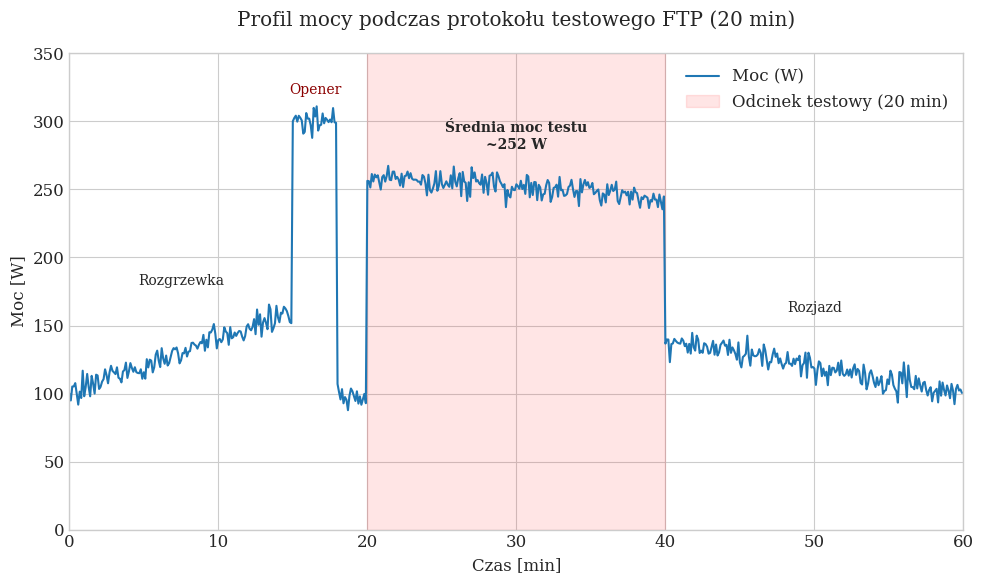

Generowanie wykresu dryfu tętna...


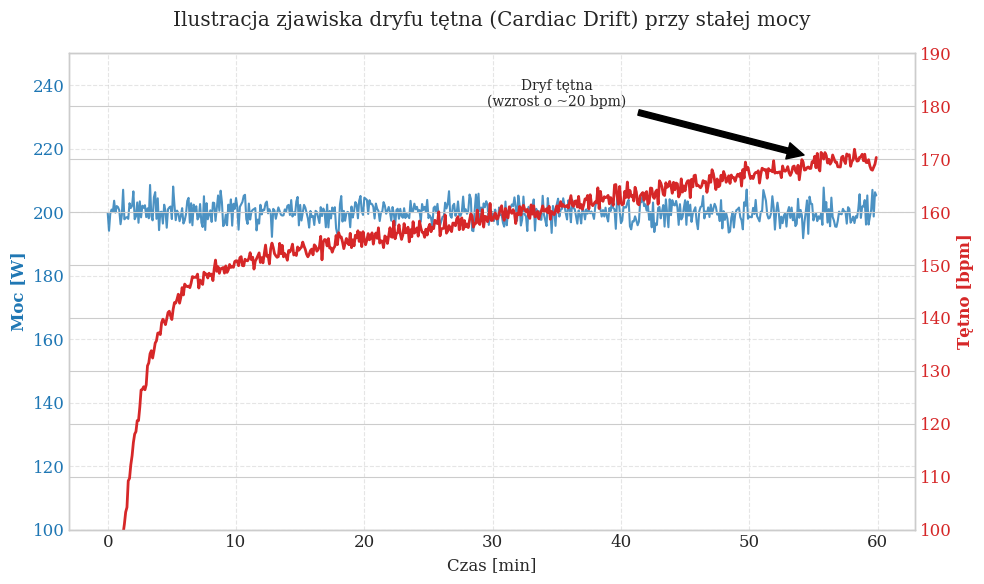

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Ustawienia stylu wykresów (styl akademicki/czytelny)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif' # Czcionka szeryfowa (np. Times New Roman) pasuje do prac dyplomowych
plt.rcParams['font.size'] = 12

def generate_ftp_test_plot():
    """Generuje wykres symulowanego testu FTP 20-minutowego"""

    # 1. Tworzenie osi czasu (w minutach) - łącznie 60 minut sesji
    time = np.arange(0, 60, 0.1) # co 6 sekund

    # 2. Symulacja Mocy (Watt)
    power = np.zeros_like(time)

    # Fazy treningu:
    # A. Rozgrzewka (0-15 min): Stopniowy wzrost 100W -> 160W + szum
    warmup_idx = (time < 15)
    power[warmup_idx] = np.linspace(100, 160, np.sum(warmup_idx))

    # B. Przepalenie/Opener (15-20 min): 3 minuty mocno (300W), 2 minuty luz
    opener_idx = (time >= 15) & (time < 18)
    rest_idx = (time >= 18) & (time < 20)
    power[opener_idx] = 300
    power[rest_idx] = 100

    # C. Główny Test (20-40 min): Stała wysoka moc ~250W (FTP estimate)
    test_idx = (time >= 20) & (time < 40)
    # Dodajemy "zmęczenie" - lekki spadek mocy pod koniec i szum
    base_test_power = 260
    fade = np.linspace(0, 15, np.sum(test_idx)) # Spadek o 15W pod koniec
    power[test_idx] = base_test_power - fade

    # D. Rozjazd (40-60 min)
    cooldown_idx = (time >= 40)
    power[cooldown_idx] = np.linspace(140, 100, np.sum(cooldown_idx))

    # Dodanie szumu (realizm pomiaru)
    noise = np.random.normal(0, 5, size=len(time))
    power = power + noise

    # --- RYSOWANIE ---
    fig, ax = plt.figure(figsize=(10, 6)), plt.gca()

    # Linia mocy
    ax.plot(time, power, color='#1f77b4', linewidth=1.5, label='Moc (W)')

    # Zaznaczenie obszaru testu (20 min)
    ax.axvspan(20, 40, color='red', alpha=0.1, label='Odcinek testowy (20 min)')

    # Opisy osi i tytuł
    ax.set_title('Profil mocy podczas protokołu testowego FTP (20 min)', pad=20)
    ax.set_xlabel('Czas [min]')
    ax.set_ylabel('Moc [W]')
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 350)

    # Adnotacje faz
    ax.text(7.5, 180, 'Rozgrzewka', ha='center', fontsize=10)
    ax.text(16.5, 320, 'Opener', ha='center', fontsize=10, color='darkred')
    ax.text(30, 280, 'Średnia moc testu\n~252 W', ha='center', fontsize=10, fontweight='bold')
    ax.text(50, 160, 'Rozjazd', ha='center', fontsize=10)

    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('test_ftp_20min.png', dpi=300) # Zapis do pliku
    plt.show()

def generate_cardiac_drift_plot():
    """Generuje wykres ilustrujący zjawisko Dryfu Tętna"""

    # Czas: 60 minut stałej jazdy
    time = np.arange(0, 60, 0.1)

    # Symulacja Mocy: Stała (np. 200W)
    power = np.full_like(time, 200) + np.random.normal(0, 3, len(time))

    # Symulacja Tętna: Szybki wzrost na początku, potem powolny dryf w górę
    # Model: nasycenie + liniowy dryf
    hr_response = 145 * (1 - np.exp(-0.5 * time)) # Szybka odpowiedź do ~145 bpm
    hr_drift = 0.4 * time # Dryf (wzrost o 24 bpm w ciągu godziny)
    # Składamy tętno, startując od spoczynkowego 60
    heart_rate = 60 + (hr_response * 0.6) + hr_drift
    # Korekta żeby startowało ładniej i szum
    heart_rate = np.clip(heart_rate, 60, 170) + np.random.normal(0, 1, len(time))

    # --- RYSOWANIE (Dwie osie Y) ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Oś lewa (Moc)
    color_p = 'tab:blue'
    ax1.set_xlabel('Czas [min]')
    ax1.set_ylabel('Moc [W]', color=color_p, fontweight='bold')
    ax1.plot(time, power, color=color_p, linewidth=1.5, alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color_p)
    ax1.set_ylim(100, 250)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Oś prawa (Tętno)
    ax2 = ax1.twinx()  # instancja drugiej osi
    color_hr = 'tab:red'
    ax2.set_ylabel('Tętno [bpm]', color=color_hr, fontweight='bold')
    ax2.plot(time, heart_rate, color=color_hr, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color_hr)
    ax2.set_ylim(100, 190)

    # Strzałka i opis dryfu
    # Zaznaczamy różnicę tętna między 10 min a 60 min przy tej samej mocy
    hr_10 = heart_rate[100] # w 10 minucie
    hr_60 = heart_rate[-1]  # w 60 minucie

    ax2.annotate(f'Dryf tętna\n(wzrost o ~{(hr_60-hr_10):.0f} bpm)',
                 xy=(55, hr_60), xytext=(35, 180),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, ha='center')

    plt.title('Ilustracja zjawiska dryfu tętna (Cardiac Drift) przy stałej mocy', pad=20)
    plt.tight_layout()
    plt.savefig('cardiac_drift.png', dpi=300) # Zapis do pliku
    plt.show()

# Uruchomienie funkcji
if __name__ == "__main__":
    print("Generowanie wykresu testu FTP...")
    generate_ftp_test_plot()
    print("Generowanie wykresu dryfu tętna...")
    generate_cardiac_drift_plot()

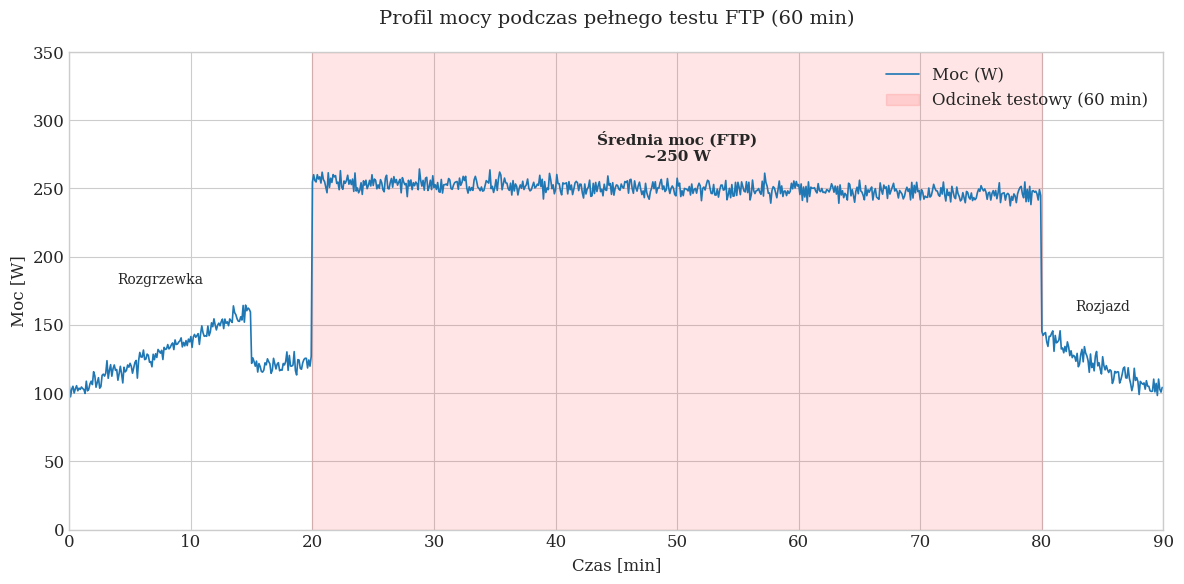

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ustawienia stylu (takie same jak poprzednio dla spójności)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

def generate_ftp_test_60min_plot():
    """Generuje wykres pełnego testu FTP trwającego 60 minut"""

    # 1. Oś czasu: Sesja musi być dłuższa, np. 90 minut (rozgrzewka + test + rozjazd)
    time = np.arange(0, 90, 0.1)

    # 2. Symulacja Mocy
    power = np.zeros_like(time)

    # --- FAZY TRENINGU ---

    # A. Rozgrzewka (0-15 min): Spokojne narastanie
    warmup_idx = (time < 15)
    power[warmup_idx] = np.linspace(100, 160, np.sum(warmup_idx))

    # B. Przygotowanie mentalne/Luz (15-20 min)
    # W teście 60-min zazwyczaj nie robi się "openerów" (przepaleń),
    # bo sam test jest wystarczająco wyczerpujący.
    rest_idx = (time >= 15) & (time < 20)
    power[rest_idx] = 120

    # C. GŁÓWNY TEST (20-80 min) -> To jest pełne 60 minut
    test_idx = (time >= 20) & (time < 80)

    # Symulacja przebiegu:
    # Start ambitny (~255W), środek stabilny (~250W), końcówka walka ze zmęczeniem (~245W)
    n_test = np.sum(test_idx)
    base_power = 250
    # Dodajemy trend liniowy (delikatny spadek w dół z powodu zmęczenia mięśniowego)
    fatigue_trend = np.linspace(5, -5, n_test)
    power[test_idx] = base_power + fatigue_trend

    # D. Rozjazd (80-90 min)
    cooldown_idx = (time >= 80)
    power[cooldown_idx] = np.linspace(140, 100, np.sum(cooldown_idx))

    # Dodanie szumu (realizm pomiaru)
    noise = np.random.normal(0, 4, size=len(time))
    power = power + noise

    # --- RYSOWANIE ---
    fig, ax = plt.figure(figsize=(12, 6)), plt.gca()

    # Linia mocy
    ax.plot(time, power, color='#1f77b4', linewidth=1.2, label='Moc (W)')

    # Zaznaczenie obszaru testu (60 min)
    # Zaczynamy w 20 minucie, kończymy w 80 minucie
    ax.axvspan(20, 80, color='red', alpha=0.1, label='Odcinek testowy (60 min)')

    # Opisy osi i tytuł
    ax.set_title('Profil mocy podczas pełnego testu FTP (60 min)', pad=20, fontsize=14)
    ax.set_xlabel('Czas [min]')
    ax.set_ylabel('Moc [W]')
    ax.set_xlim(0, 90)
    ax.set_ylim(0, 350)

    # Adnotacje
    ax.text(7.5, 180, 'Rozgrzewka', ha='center', fontsize=10)

    # Etykieta średniej mocy
    ax.text(50, 270, 'Średnia moc (FTP)\n~250 W', ha='center', fontsize=11, fontweight='bold')

    ax.text(85, 160, 'Rozjazd', ha='center', fontsize=10)

    plt.legend(loc='upper right')
    plt.tight_layout()

    # Zapisz i pokaż
    plt.savefig('test_ftp_60min.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    generate_ftp_test_60min_plot()